# Tutorial 05 — Minimization, Constraints, and Kinematics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/05_minimization_constraints_kinematics.ipynb)

This tutorial minimizes a small structure, limits which degrees of freedom may move, and adds coordinate or distance constraints.

## Learning objectives

- Run Cartesian minimization with an atom-coordinate mask.
- Run kinematic minimization with a `MoveMap` and `FoldForest`.
- Add a constraint and inspect its effect on score and geometry.

## Before you begin

- **Prerequisites:** [03 — Scoring and analysis](03_scoring_and_analysis.ipynb), including score terms and coordinate gradients.
- **Curriculum:** This is the continuous-sampling branch after 03. Complete the parallel [04 — Packing](04_packing_and_mutation_scan.ipynb) branch before [06 — FastRelax](06_fast_relax.ipynb) combines both.
- **Related:** [Optimization workflow](../user_guide/optimization.md) · [Kinematics API](../api/kinematics.rst)

The short runs are smoke tests, not convergence studies. They run on CPU; larger systems benefit from CUDA.

## Setup

The examples use a checked-in eight-residue 1UBQ slice on the selected CPU or CUDA device. A fixed constraint weight and ten minimizer iterations keep the Cartesian and kinematic runs suitable for documentation smoke tests; later sections explain why finite output is not evidence of convergence.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import warnings

import attrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.io import pose_stack_from_biotite
from tmol.kinematics import CartesianMoveMap, EdgeType, FoldForest, MoveMap
from tmol.ops import res_mask_to_coord_mask
from tmol.optimization import run_cart_min, run_kin_min
from tmol.pose import ConstraintSet, PoseStackBuilder
from tmol.score import ScoreType, beta2016_score_function
from tmol.score.constraint import (
    ConstraintEnergyTerm,
    create_mainchain_coordinate_constraints,
)

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)


def show_table(frame):
    """Use a sortable docs table when available, otherwise display pandas."""
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def score_components(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    weighted_terms = scorer(
        pose_stack.coords, sum_terms=False, apply_weights=True
    )[:, 0]
    score_types = score_function.all_score_types()
    constraint_index = next(
        index
        for index, score_type in enumerate(score_types)
        if score_type == ScoreType.constraint
    )
    constraint_score = weighted_terms[constraint_index]
    non_constraint_score = weighted_terms.sum() - constraint_score
    return {
        "non_constraint_score_units": float(non_constraint_score.detach().cpu()),
        "constraint_score_units": float(constraint_score.detach().cpu()),
        "reported_total_score_units": float(weighted_terms.sum().detach().cpu()),
    }


def common_atom_mask(reference, mobile, atom_mask=None):
    finite = torch.isfinite(reference.coords).all(dim=-1)
    finite &= torch.isfinite(mobile.coords).all(dim=-1)
    return finite if atom_mask is None else finite & atom_mask


def rms_displacement(reference, mobile, atom_mask=None):
    """Raw RMS displacement in the input frame; no superposition is applied."""
    mask = common_atom_mask(reference, mobile, atom_mask)
    delta = mobile.coords[mask] - reference.coords[mask]
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def kabsch_aligned_rmsd(reference, mobile, atom_mask=None):
    """RMSD after least-squares rigid-body superposition of mobile onto reference."""
    mask = common_atom_mask(reference, mobile, atom_mask)
    reference_xyz = reference.coords[mask]
    mobile_xyz = mobile.coords[mask]
    reference_centered = reference_xyz - reference_xyz.mean(dim=0)
    mobile_centered = mobile_xyz - mobile_xyz.mean(dim=0)

    covariance = mobile_centered.T @ reference_centered
    u, _, vh = torch.linalg.svd(covariance)
    handedness = torch.sign(torch.det(u @ vh))
    correction = torch.eye(3, device=mobile_xyz.device, dtype=mobile_xyz.dtype)
    correction[-1, -1] = handedness
    rotation = u @ correction @ vh
    aligned_mobile = mobile_centered @ rotation
    delta = aligned_mobile - reference_centered
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def declared_mainchain_atom_mask(pose_stack):
    """Select atoms named in each residue type's TMol polymer declaration."""
    mask = torch.zeros_like(pose_stack.real_atoms)
    atom_names = []
    seen_atom_names = set()
    for pose_index in range(pose_stack.n_poses):
        for block_index in range(pose_stack.max_n_blocks):
            block_type_index = int(
                pose_stack.block_type_ind64[pose_index, block_index].item()
            )
            if block_type_index < 0:
                continue
            block_type = pose_stack.packed_block_types.active_block_types[
                block_type_index
            ]
            polymer = block_type.properties.polymer
            if polymer is None:
                continue
            atom_offset = int(
                pose_stack.block_coord_offset64[pose_index, block_index].item()
            )
            for atom_name in polymer.mainchain_atoms:
                atom_index = atom_offset + block_type.atom_to_idx[atom_name]
                if bool(pose_stack.real_atoms[pose_index, atom_index]):
                    mask[pose_index, atom_index] = True
                    if atom_name not in seen_atom_names:
                        atom_names.append(atom_name)
                        seen_atom_names.add(atom_name)
    return mask, tuple(atom_names)

## Build a small pose and compare FoldForests

`FoldForest.reasonable_fold_forest()` derives polymer and jump edges from backbone connectivity. Each edge is `(type, start block, end block, jump index)`, and the edge array is batched over poses.

The same contiguous chain is also written explicitly with `FoldForest.from_edges()`. Finally, a per-residue-root or “dandelion” forest attaches every real block to the virtual root. That representation matches neural-network models that predict one frame per residue while retaining internal side-chain geometry; it changes the movable DOFs and is not a generic replacement for a polymer forest.

In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 8)]
pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        start = pose_stack_from_biotite(protein_slice, device, no_optH=True)
except Exception:
    print(pose_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fold_forest = FoldForest.reasonable_fold_forest(start)

explicit_edges = np.full((1, 2, 4), -1, dtype=np.int64)
explicit_edges[0, 0] = [int(EdgeType.root_jump), -1, 0, -1]
explicit_edges[0, 1] = [
    int(EdgeType.polymer),
    0,
    start.max_n_blocks - 1,
    -1,
]
explicit_fold_forest = FoldForest.from_edges(explicit_edges)

# One root edge per real block: useful for per-residue NN frames.
dandelion_edges = np.full(
    (start.n_poses, start.max_n_blocks, 4), -1, dtype=np.int64
)
dandelion_edges[:, :, 0] = int(EdgeType.root_jump)
dandelion_edges[:, :, 1] = -1
dandelion_edges[:, :, 2] = np.arange(start.max_n_blocks)[None, :]
per_residue_root_forest = FoldForest.from_edges(dandelion_edges)
assert int(per_residue_root_forest.n_edges[0]) == start.max_n_blocks

edge_names = {int(edge): edge.name for edge in EdgeType}
edge_rows = []
for forest_name, forest in (
    ("automatic polymer", fold_forest),
    ("explicit polymer", explicit_fold_forest),
    ("per-residue root / dandelion", per_residue_root_forest),
):
    for pose_i in range(start.n_poses):
        for edge_i in range(int(forest.n_edges[pose_i])):
            edge_type, begin, end, jump_index = forest.edges[pose_i, edge_i]
            edge_rows.append(
                {
                    "forest": forest_name,
                    "pose": pose_i,
                    "edge": edge_i,
                    "type": edge_names[int(edge_type)],
                    "start": int(begin),
                    "end": int(end),
                    "jump_index": int(jump_index),
                }
            )

print("input:", cif_path.name)
print("automatic FoldForest edge tensor shape:", fold_forest.edges.shape)
show_table(pd.DataFrame(edge_rows))

input: 1UBQ.cif
automatic FoldForest edge tensor shape: (1, 2, 4)


**Expected observations.** The automatic and explicit polymer forests each contain a `root_jump` whose start is `-1`, followed by a polymer edge covering the contiguous 1UBQ slice. The dandelion forest instead has one `root_jump` per real block and no polymer edge. A `jump_index` of `-1` is expected for root-jump and polymer edges; only ordinary jumps receive contiguous non-negative jump indices. Missing, duplicated, or overlapping coverage indicates a malformed forest and should be investigated before minimization.

TMol's `FoldForest` differs from Rosetta's `FoldTree` in one important invariant: every TMol forest has an explicit virtual root at the origin. `reasonable_fold_forest()` follows backbone up/down connections, turns same-chain gaps into jumps, and roots separate chains independently. Its current automatic builder intentionally ignores non-polymer connections such as disulfides.

## Executable constrained and unconstrained workflow

`run_cart_min` accepts `(pose_stack, sfxn, coord_mask=None, optimizer_cls=..., optimizer_kwargs=None, verbose=False)`. `run_kin_min` accepts `(pose_stack, sfxn, ff, mm, optimizer_cls=..., optimizer_kwargs=None, verbose=False, kin_dtype=...)`.

### One meaningful low-level distance restraint

A `ConstraintSet` identifies atoms by `(pose, block, atom-within-block)`. The code adds one harmonic distance restraint between the first and last Cα atoms of this eight-residue fragment, targeted to their input distance with σ = 0.5 Å. It then uses `add_constraints_to_all_poses()` to replicate that same block-local definition across a two-pose batch. The restraint is linear in system size and tied to an explicit structural hypothesis.

### Declared-main-chain coordinate restraints

`create_mainchain_coordinate_constraints()` follows each residue type's `mainchain_atoms` declaration. For the standard amino acids in this fixture those atoms are **N, CA, and C**; O is not declared as main chain and is not constrained. The helper uses harmonic-coordinate σ = 0.5 Å and retains existing constraints. This residue-type-driven definition is preferable to assuming that every block contains a protein Cα atom.

The score-function constraint weight is 1.0 for this TMol demonstration. Rosetta constraint weights are protocol-specific, so score magnitudes should not be compared without matching constraint definitions, functional forms, and weights.

### Cartesian and kinematic degrees of freedom

The Cartesian runs move every finite atom coordinate independently. Without coordinate restraints, a single isolated molecule has global translation and rotation directions that do not change its internal score: six rigid-body null modes. Raw displacement can therefore include arbitrary frame drift, whereas Kabsch-aligned RMSD removes the best global translation and rotation before measuring internal change.

The kinematic runs below explicitly fix ordinary jumps and the virtual-root jump, so the chain cannot translate or rotate as a rigid body. `move_all_named_torsions=True` enables both named main-chain and side-chain torsions; with the default ideal kinematics it does not independently optimize bond lengths and angles. By contrast, Cartesian minimization can distort local geometry, but beta2016 actively penalizes it through the nonzero cartbonded score terms `cart_lengths`, `cart_angles`, `cart_torsions`, `cart_impropers`, and `cart_hxltorsions` (each weighted 0.5). Thus Cartesian and kinematic runs are different coordinate models, not interchangeable optimizers over identical degrees of freedom.

In [4]:
cartesian_move_map = CartesianMoveMap(
    coord_mask=torch.isfinite(start.coords).all(dim=-1)
)
kinematic_move_map = MoveMap.from_pose_stack(start)
kinematic_move_map.move_all_named_torsions = True  # named MC and SC torsions
kinematic_move_map.move_all_jumps = False
kinematic_move_map.move_all_root_jumps = False

mainchain_mask, restrained_atom_names = declared_mainchain_atom_mask(start)
constraint_diagnostics = StringIO()
try:
    with redirect_stdout(constraint_diagnostics), redirect_stderr(constraint_diagnostics):
        constrained_start = create_mainchain_coordinate_constraints(start.clone())
except Exception:
    print(constraint_diagnostics.getvalue())
    raise

# One low-level Cα distance restraint, expressed in block-local atom indices.
first_block, last_block = 0, start.max_n_blocks - 1
first_ca = start.block_type(0, first_block).atom_to_idx["CA"]
last_ca = start.block_type(0, last_block).atom_to_idx["CA"]
first_coord_index = int(start.block_coord_offset64[0, first_block]) + first_ca
last_coord_index = int(start.block_coord_offset64[0, last_block]) + last_ca
target_distance = torch.linalg.vector_norm(
    start.coords[0, first_coord_index] - start.coords[0, last_coord_index]
)
distance_atoms = torch.tensor(
    [[[0, first_block, first_ca], [0, last_block, last_ca]]],
    dtype=torch.int32,
    device=device,
)
distance_params = torch.zeros((1, 4), dtype=torch.float32, device=device)
distance_params[0, 0] = target_distance
distance_params[0, 1] = 0.5
distance_constraint_set = ConstraintSet.create_empty(device, 1).add_constraints(
    ConstraintEnergyTerm.harmonic,
    distance_atoms,
    distance_params,
)
distance_constrained_start = attrs.evolve(
    start, constraint_set=distance_constraint_set
)

constraint_batch = PoseStackBuilder.from_poses([start] * 2, device)
batch_constraint_set = ConstraintSet.create_empty(
    device, constraint_batch.n_poses
).add_constraints_to_all_poses(
    ConstraintEnergyTerm.harmonic,
    distance_atoms,
    distance_params,
)
distance_constrained_batch = attrs.evolve(
    constraint_batch, constraint_set=batch_constraint_set
)
assert len(distance_constraint_set.constraint_function_inds) == 1
assert len(batch_constraint_set.constraint_function_inds) == 2

CONSTRAINT_SIGMA_A = 0.5
constraint_weight = float(score_function.get_weight(ScoreType.constraint))
print(
    f"distance restraint: block {first_block} CA ↔ block {last_block} CA; "
    f"target={float(target_distance):.3f} Å; sigma=0.5 Å"
)
print(
    "distance constraints in one pose / replicated batch:",
    len(distance_constraint_set.constraint_function_inds),
    "/",
    len(batch_constraint_set.constraint_function_inds),
)
print(
    "declared-main-chain coordinate restraints:",
    len(constrained_start.constraint_set.constraint_function_inds),
)
print("coordinate-restraint atom names:", ", ".join(restrained_atom_names))
print("coordinate-restraint count:", int(mainchain_mask.sum().item()))
print(f"coordinate-restraint sigma: {CONSTRAINT_SIGMA_A:.1f} Å")
print(f"coordinate-restraint score weight: {constraint_weight:.1f}")
print("O is not TMol-declared main chain here and is not constrained.")
print("Weight 1.0 is intentional; constraint weights are protocol-specific.")

# Strictly a short smoke-test budget for tutorial/CI runtime. Finite output and
# a lower objective after ten iterations do not demonstrate convergence.
TUTORIAL_MAX_ITER = 10
optimizer_kwargs = {"max_iter": TUTORIAL_MAX_ITER}
print(f"smoke-test optimizer max_iter: {TUTORIAL_MAX_ITER} (convergence not assessed)")

# Every branch starts from the same coordinates, score function, and iteration
# budget. Within each coordinate model, only the presence of restraints changes.
cart_unconstrained = run_cart_min(
    start.clone(),
    score_function,
    coord_mask=cartesian_move_map.coord_mask,
    optimizer_kwargs=optimizer_kwargs,
)
cart_constrained = run_cart_min(
    constrained_start.clone(),
    score_function,
    coord_mask=cartesian_move_map.coord_mask,
    optimizer_kwargs=optimizer_kwargs,
)
kin_unconstrained = run_kin_min(
    start.clone(),
    score_function,
    fold_forest,
    kinematic_move_map,
    optimizer_kwargs=optimizer_kwargs,
)
kin_constrained = run_kin_min(
    constrained_start.clone(),
    score_function,
    fold_forest,
    kinematic_move_map,
    optimizer_kwargs=optimizer_kwargs,
)

distance restraint: block 0 CA ↔ block 7 CA; target=23.155 Å; sigma=0.5 Å
distance constraints in one pose / replicated batch: 1 / 2
declared-main-chain coordinate restraints: 24
coordinate-restraint atom names: N, CA, C
coordinate-restraint count: 24
coordinate-restraint sigma: 0.5 Å
coordinate-restraint score weight: 1.0
O is not TMol-declared main chain here and is not constrained.
Weight 1.0 is intentional; constraint weights are protocol-specific.
smoke-test optimizer max_iter: 10 (convergence not assessed)


/tmp/ipykernel_4426/382234577.py:78: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


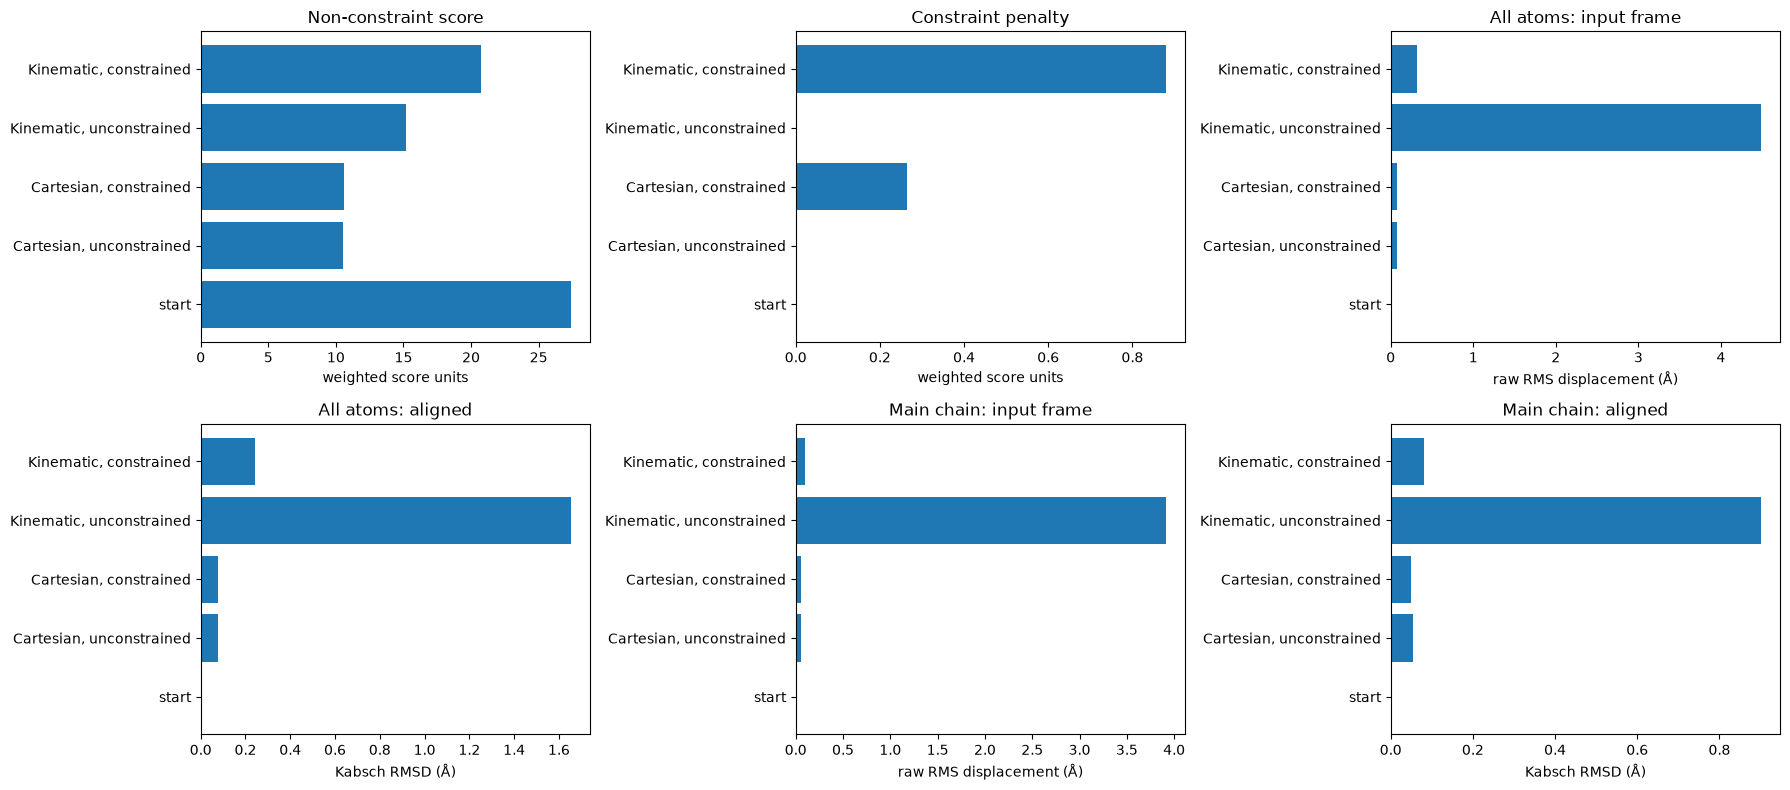

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
variants = {
    "Cartesian, unconstrained": cart_unconstrained,
    "Cartesian, constrained": cart_constrained,
    "Kinematic, unconstrained": kin_unconstrained,
    "Kinematic, constrained": kin_constrained,
}
mainchain_mask, _ = declared_mainchain_atom_mask(start)
start_components = score_components(start, score_function)
rows = [
    {
        "variant": "start",
        **start_components,
        "non_constraint_score_change_units": 0.0,
        "constraint_score_change_units": 0.0,
        "objective_change_units": 0.0,
        "all_atom_raw_RMS_displacement_A": 0.0,
        "all_atom_Kabsch_RMSD_A": 0.0,
        "mainchain_raw_RMS_displacement_A": 0.0,
        "mainchain_Kabsch_RMSD_A": 0.0,
        "finite_smoke_test_output": True,
        "convergence_status": "not assessed",
    }
]
for name, pose_stack in variants.items():
    components = score_components(pose_stack, score_function)
    all_atom_raw = rms_displacement(start, pose_stack)
    all_atom_aligned = kabsch_aligned_rmsd(start, pose_stack)
    mainchain_raw = rms_displacement(start, pose_stack, mainchain_mask)
    mainchain_aligned = kabsch_aligned_rmsd(start, pose_stack, mainchain_mask)
    numeric_outputs = (
        *components.values(),
        all_atom_raw,
        all_atom_aligned,
        mainchain_raw,
        mainchain_aligned,
    )
    rows.append(
        {
            "variant": name,
            **components,
            "non_constraint_score_change_units": (
                components["non_constraint_score_units"]
                - start_components["non_constraint_score_units"]
            ),
            "constraint_score_change_units": (
                components["constraint_score_units"]
                - start_components["constraint_score_units"]
            ),
            "objective_change_units": (
                components["reported_total_score_units"]
                - start_components["reported_total_score_units"]
            ),
            "all_atom_raw_RMS_displacement_A": all_atom_raw,
            "all_atom_Kabsch_RMSD_A": all_atom_aligned,
            "mainchain_raw_RMS_displacement_A": mainchain_raw,
            "mainchain_Kabsch_RMSD_A": mainchain_aligned,
            "finite_smoke_test_output": bool(np.isfinite(numeric_outputs).all()),
            "convergence_status": "not assessed (10-iteration smoke test)",
        }
    )
comparison_frame = pd.DataFrame(rows)
show_table(comparison_frame)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()
axes[0].barh(
    comparison_frame["variant"], comparison_frame["non_constraint_score_units"]
)
axes[0].set(xlabel="weighted score units", title="Non-constraint score")
axes[1].barh(
    comparison_frame["variant"], comparison_frame["constraint_score_units"]
)
axes[1].set(xlabel="weighted score units", title="Constraint penalty")
axes[2].barh(
    comparison_frame["variant"],
    comparison_frame["all_atom_raw_RMS_displacement_A"],
)
axes[2].set(xlabel="raw RMS displacement (Å)", title="All atoms: input frame")
axes[3].barh(
    comparison_frame["variant"], comparison_frame["all_atom_Kabsch_RMSD_A"]
)
axes[3].set(xlabel="Kabsch RMSD (Å)", title="All atoms: aligned")
axes[4].barh(
    comparison_frame["variant"],
    comparison_frame["mainchain_raw_RMS_displacement_A"],
)
axes[4].set(xlabel="raw RMS displacement (Å)", title="Main chain: input frame")
axes[5].barh(
    comparison_frame["variant"], comparison_frame["mainchain_Kabsch_RMSD_A"]
)
axes[5].set(xlabel="Kabsch RMSD (Å)", title="Main chain: aligned")
plt.tight_layout()
plt.show()

try:
    restraint_viewer = tmol.view(
        start,
        highlighted=mainchain_mask[start.real_atoms],
        highlight_color="#7b2cbf",
    )
    restraint_viewer.show()
except ImportError:
    print("Install py3Dmol to inspect the restrained main-chain atoms.")

viewer_structures = {"before": start, **variants}
viewer_notes = {"before": "Starting 1UBQ slice"}
for row in rows[1:]:
    viewer_notes[row["variant"]] = (
        f"objective change {row['objective_change_units']:+.3f} score units; "
        f"non-constraint {row['non_constraint_score_units']:.3f}; "
        f"constraint {row['constraint_score_units']:.3f}; "
        f"main-chain raw/aligned "
        f"{row['mainchain_raw_RMS_displacement_A']:.3f}/"
        f"{row['mainchain_Kabsch_RMSD_A']:.3f} Å; convergence not assessed"
    )
display(tmol.switchable_view(viewer_structures, notes=viewer_notes))

**Expected observations.** Every minimized structure should have finite weighted scores, score/objective changes, raw displacements, and aligned RMSDs. Finite output—or even a lower objective—after `max_iter=10` is only a smoke-test result and must not be described as convergence. Establish convergence separately with a suitable iteration budget, stopping diagnostics, and repeatability checks. All-atom metrics include side-chain motion produced by minimization; no packing occurs in this notebook. Main-chain metrics use exactly the restrained TMol-declared N/CA/C atoms, highlighted in purple; O is excluded.

Raw RMS displacement compares coordinates in the original laboratory frame. Kabsch RMSD first removes the best global translation and rotation. A large raw-versus-aligned gap in the unconstrained Cartesian result is evidence of rigid-body drift along its null modes, not the same thing as internal deformation. The kinematic root jump is fixed, so that branch has no equivalent whole-chain drift. Coordinate restraints should generally reduce main-chain motion relative to the matching unconstrained run. Those within-parameterization pairs are controlled comparisons; Cartesian and kinematic endpoints need not agree because their active degrees of freedom differ. The score columns are weighted TMol score units, not physical kcal/mol.


## Restraint-guided rescue of a displaced local segment

The preceding comparison starts from a deposited structure. This controlled rescue experiment creates an explicit defect: all atoms in zero-based blocks 3–4 are translated by the same vector while blocks 2–6 define the movable local shell. Three short Cartesian runs then start from exactly that perturbed structure:

- no restraints;
- reference main-chain coordinate restraints copied from the unperturbed pose; or
- one reference Cα–Cα distance restraint linking fixed-side block 1 to displaced block 4.

The experiment asks how restraint information trades against the non-constraint score and recovery toward the known reference. It is a method diagnostic, not loop modeling or structure prediction.


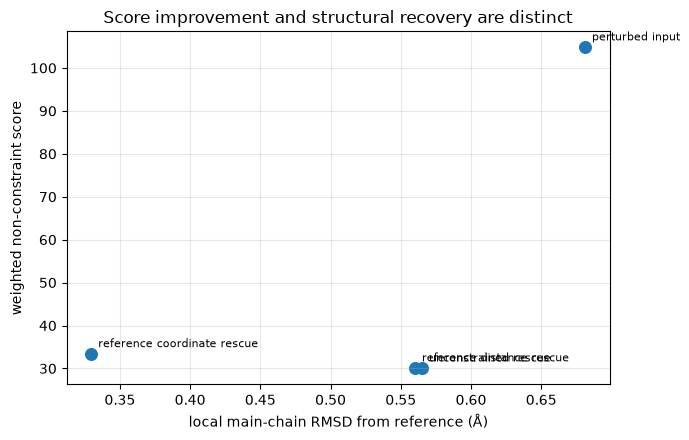

In [6]:
local_blocks = torch.zeros_like(start.block_type_ind, dtype=torch.bool)
local_blocks[:, 2:7] = True
displaced_blocks = torch.zeros_like(local_blocks)
displaced_blocks[:, 3:5] = True
local_coord_mask = res_mask_to_coord_mask(start, local_blocks) & start.real_atoms
displaced_coord_mask = (
    res_mask_to_coord_mask(start, displaced_blocks) & start.real_atoms
)
local_mainchain_mask = mainchain_mask & local_coord_mask

perturbed = start.clone()
displacement = torch.tensor(
    [0.8, -0.6, 0.4], device=device, dtype=perturbed.coords.dtype
)
perturbed.coords[displaced_coord_mask] += displacement

# The coordinate-constraint targets were created from the unperturbed start.
coordinate_rescue_start = attrs.evolve(
    perturbed.clone(), constraint_set=constrained_start.constraint_set
)

anchor_block, rescued_block = 1, 4
anchor_ca = start.block_type(0, anchor_block).atom_to_idx["CA"]
rescued_ca = start.block_type(0, rescued_block).atom_to_idx["CA"]
anchor_coord = int(start.block_coord_offset64[0, anchor_block]) + anchor_ca
rescued_coord = int(start.block_coord_offset64[0, rescued_block]) + rescued_ca
rescue_target_distance = torch.linalg.vector_norm(
    start.coords[0, anchor_coord] - start.coords[0, rescued_coord]
)
rescue_atoms = torch.tensor(
    [[[0, anchor_block, anchor_ca], [0, rescued_block, rescued_ca]]],
    dtype=torch.int32,
    device=device,
)
rescue_params = torch.zeros((1, 4), dtype=torch.float32, device=device)
rescue_params[0, 0] = rescue_target_distance
rescue_params[0, 1] = 0.5
rescue_distance_set = ConstraintSet.create_empty(device, 1).add_constraints(
    ConstraintEnergyTerm.harmonic,
    rescue_atoms,
    rescue_params,
)
distance_rescue_start = attrs.evolve(
    perturbed.clone(), constraint_set=rescue_distance_set
)

rescue_budget = {"max_iter": 15}
rescue_variants = {
    "perturbed input": perturbed,
    "unconstrained rescue": run_cart_min(
        perturbed.clone(),
        score_function,
        coord_mask=local_coord_mask,
        optimizer_kwargs=rescue_budget,
    ),
    "reference coordinate rescue": run_cart_min(
        coordinate_rescue_start,
        score_function,
        coord_mask=local_coord_mask,
        optimizer_kwargs=rescue_budget,
    ),
    "reference distance rescue": run_cart_min(
        distance_rescue_start,
        score_function,
        coord_mask=local_coord_mask,
        optimizer_kwargs=rescue_budget,
    ),
}

rescue_rows = []
for label, pose_stack in rescue_variants.items():
    components = score_components(pose_stack, score_function)
    observed_distance = torch.linalg.vector_norm(
        pose_stack.coords[0, anchor_coord] - pose_stack.coords[0, rescued_coord]
    )
    rescue_rows.append(
        {
            "state": label,
            **components,
            "local_mainchain_RMSD_from_reference_A": rms_displacement(
                start, pose_stack, local_mainchain_mask
            ),
            "reference_distance_error_A": abs(
                float(observed_distance.detach().cpu())
                - float(rescue_target_distance.detach().cpu())
            ),
            "movable_atoms": int(local_coord_mask.sum().item()),
            "optimizer_budget": (
                "input only"
                if label == "perturbed input"
                else "15-iteration smoke test; convergence not assessed"
            ),
        }
    )
rescue_frame = pd.DataFrame(rescue_rows)
show_table(rescue_frame)

fig, axis = plt.subplots(figsize=(7, 4.5))
axis.scatter(
    rescue_frame["local_mainchain_RMSD_from_reference_A"],
    rescue_frame["non_constraint_score_units"],
    s=70,
)
for row in rescue_frame.itertuples():
    axis.annotate(
        row.state,
        (
            row.local_mainchain_RMSD_from_reference_A,
            row.non_constraint_score_units,
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
axis.set(
    xlabel="local main-chain RMSD from reference (Å)",
    ylabel="weighted non-constraint score",
    title="Score improvement and structural recovery are distinct",
)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(
    tmol.switchable_view(
        {"reference": start, **rescue_variants},
        notes={
            "reference": "Unperturbed eight-residue reference",
            **{
                row.state: (
                    f"local main-chain RMSD "
                    f"{row.local_mainchain_RMSD_from_reference_A:.3f} Å; "
                    f"distance error {row.reference_distance_error_A:.3f} Å; "
                    f"non-constraint score {row.non_constraint_score_units:.2f}"
                )
                for row in rescue_frame.itertuples()
            },
        },
    )
)

**Expected observations.** All three minimized states should reduce the severe score penalty created by the displacement, but their structural recovery need not track score improvement exactly. Reference coordinate restraints should generally pull the moved main chain closer to the known starting geometry. One scalar distance restraint supplies much less information and cannot uniquely determine a local conformation. Finite output after 15 iterations is smoke-test evidence only; convergence and recovery quality must be assessed separately.


## Rosetta comparison

Rosetta's `MinMover` and Cartesian minimization use a `MoveMap` to select internal or Cartesian degrees of freedom. TMol separates these concepts into `MoveMap` for named torsion/jump DOFs and `CartesianMoveMap` for per-atom coordinate masks that apply across a `PoseStack`. Rosetta Cartesian workflows commonly choose a Cartesian-ready score function; TMol beta2016 already weights its five `cart_*` bonded terms.

Rosetta `FoldTree` can root on a physical residue and combines chemical and jump connectivity in one tree. TMol `FoldForest` is batched, always uses a virtual root, and its automatic builder follows polymer connectivity but not disulfides; use validated custom edges when needed.

Rosetta supports text constraint files and ambiguous or multi constraints. TMol instead assembles supported harmonic distance/coordinate, bounded-distance, and circular-harmonic torsion constraints through `ConstraintSet` and `ConstraintEnergyTerm`; it has no Rosetta constraint-file parser, ambiguous-constraint layer, or dedicated three-atom angle constraint. Circular-harmonic torsion differences are compared periodically across the −π/+π boundary.

For executable PyRosetta context, compare [05.01 — High-Resolution Movers](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/05.01-High-Res-Movers.ipynb) and [05.02 — Refinement Protocol](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/05.02-Refinement-Protocol.ipynb). The APIs and numerical defaults are not interchangeable; reproduce a protocol only after matching its score function, active degrees of freedom, restraints, and optimizer settings.

The [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md) summarizes these API and protocol boundaries.

## Next: compose packing and minimization

After completing the parallel packing/design branch in [Tutorial 04](04_packing_and_mutation_scan.ipynb), continue to [06 — FastRelax](06_fast_relax.ipynb), which alternates packing with the Cartesian or kinematic minimization interfaces used here.

## Exercises

1. Change the Cartesian coordinate mask so only residues 3–5 move, then compare the displacement table.
2. Disable side-chain torsions in the kinematic `MoveMap` and enable only main-chain torsions for selected blocks.
3. Replace the one Cα–Cα harmonic restraint with a tested `ConstraintEnergyTerm.bounded` distance constraint and verify its two-pose replication.
4. Build a two-chain slice and compare its automatic forest with an explicit `FoldForest.from_edges()` definition.
5. Apply `create_mainchain_coordinate_constraints()` to a mixed protein–nucleic-acid pose and inspect the atoms selected from each residue type's declared main chain.

## References

- [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md)
- [Rosetta minimization tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/minimization/minimization)
- [Rosetta constraints tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Constraints_Tutorial/Constraints)
- [Rosetta FoldTree tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/fold_tree/fold_tree)
- [PyRosetta 05.01 — High-Resolution Movers](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/05.01-High-Res-Movers.ipynb)
- [PyRosetta 05.02 — Refinement Protocol](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/05.02-Refinement-Protocol.ipynb)
- [Rosetta `FoldTree.hh`](https://github.com/RosettaCommons/rosetta/blob/main/source/src/core/kinematics/FoldTree.hh)
- [Rosetta `ConstraintSet.cc`](https://github.com/RosettaCommons/rosetta/blob/main/source/src/core/scoring/constraints/ConstraintSet.cc)